In [35]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [36]:
# Конфигурация
class CFG:
    TARGET = ['GGFM_f']
    SEQUENCE_LENGTH = 10  # Длина последовательности для RNN
    BATCH_SIZE = 32
    HIDDEN_SIZE = 64
    NUM_LAYERS = 2
    DROPOUT = 0.3
    LEARNING_RATE = 0.001
    EPOCHS = 100
    RANDOM_STATE = 3
    TEST_SIZE = 0.2
    
    COLORADO_PATH_TRAIN = './Data/Synt/Colorado_600_merge.csv'
    COLORADO_PATH_TEST = './Data/Synt/Colorado_60000_merge.csv'

In [37]:
# Модель RNN
class GravityRNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout, output_size=1):
        super(GravityRNN, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.rnn = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, output_size)
        
    def forward(self, x):
        # x shape: (batch_size, seq_len, input_size)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        out, _ = self.rnn(x, h0)
        out = self.dropout(out[:, -1, :])  # Берем только последний выход последовательности
        out = self.fc(out)
        return out

In [38]:
# Функция для нормального гравитационного потенциала
def normal_gravitational_potential_grs80(latitude_deg, height):
    """
    Вычисляет нормальный гравитационный потенциал V (в м²/с²)
    по широте и высоте над эллипсоидом GRS80
    """
    # Константы GRS80
    a = 6378137.0              # большая полуось, м
    GM = 3.986004418e14        # гравитационная постоянная, м³/с²
    J2 = 1.08263e-3            # коэффициент J2
    e2 = 0.00669438002290      # квадрат первого эксцентриситета

    # Переводим широту в радианы
    phi = np.radians(latitude_deg)
    sin_phi = np.sin(phi)
    cos_phi = np.cos(phi)
    sin2_phi = sin_phi * sin_phi

    # Радиус кривизны в первом вертикале
    N = a / np.sqrt(1 - e2 * sin2_phi)

    # Вычисляем r — расстояние от центра Земли до точки
    term_eq = (N + height) * cos_phi
    term_pol = (N * (1 - e2) + height) * sin_phi
    r = np.sqrt(term_eq**2 + term_pol**2)

    # Вычисляем J2-член
    a_over_r = a / r
    P2_term = 0.5 * (3 * sin2_phi - 1)
    j2_correction = J2 * (a_over_r ** 2) * P2_term

    # Гравитационный потенциал
    V = (GM / r) * (1 - j2_correction)

    return V

In [39]:
# Функция для создания последовательностей
def create_sequences(data, target, sequence_length):
    sequences = []
    targets = []
    
    for i in range(len(data) - sequence_length):
        seq = data[i:i+sequence_length]
        label = target[i+sequence_length]
        sequences.append(seq)
        targets.append(label)
    
    return np.array(sequences), np.array(targets)

In [40]:
# Загрузка и подготовка данных
def load_and_prepare_data():
    print("Загрузка и подготовка данных...")
    
    # Загрузка обучающих данных
    train_data = pd.read_csv(CFG.COLORADO_PATH_TRAIN, skipinitialspace=True, index_col='index')
    test_data = pd.read_csv(CFG.COLORADO_PATH_TEST, skipinitialspace=True, index_col='index')
    
    # Вычисление нормального потенциала и вычитание
    print("Вычисление нормального потенциала...")
    for data, name in zip([train_data, test_data], ['Train', 'Test']):
        print(f"Обработка {name} данных...")
        normal_potentials = normal_gravitational_potential_grs80(
            data["Latitude (deg)"].values, 
            data["Height (m)"].values
        )
        # Правильное вычитание - убеждаемся, что размерности совпадают
        if len(normal_potentials.shape) == 1:
            normal_potentials = normal_potentials.reshape(-1, 1)
        
        # Вычитаем нормальный потенциал из целевой переменной
        data[CFG.TARGET[0]] = data[CFG.TARGET[0]].values - normal_potentials.flatten()
        
        # Удаляем лишние столбцы если они существуют
        cols_to_drop = [col for col in ['GGFM_g', 'gravity(mGal)'] if col in data.columns]
        if cols_to_drop:
            data.drop(columns=cols_to_drop, inplace=True)
    
    # Выбор признаков
    feature_columns = [
        col for col in train_data.columns 
        if col not in ['Latitude (deg)', 'Longitude (deg)', 'Height (m)'] + CFG.TARGET
    ]
    
    print(f"Используемые признаки: {feature_columns}")
    
    # Масштабирование признаков
    scaler_X = StandardScaler()
    X_train = scaler_X.fit_transform(train_data[feature_columns])
    X_test = scaler_X.transform(test_data[feature_columns])
    
    # Масштабирование целевой переменной
    scaler_y = StandardScaler()
    y_train = scaler_y.fit_transform(train_data[CFG.TARGET].values).flatten()
    y_test = scaler_y.transform(test_data[CFG.TARGET].values).flatten()
    
    # Координаты для визуализации
    coords_train = train_data[['Latitude (deg)', 'Longitude (deg)', 'Height (m)']].values
    coords_test = test_data[['Latitude (deg)', 'Longitude (deg)', 'Height (m)']].values
    
    # Создание последовательностей для RNN
    print(f"Создание последовательностей длиной {CFG.SEQUENCE_LENGTH}...")
    X_train_seq, y_train_seq = create_sequences(X_train, y_train, CFG.SEQUENCE_LENGTH)
    X_test_seq, y_test_seq = create_sequences(X_test, y_test, CFG.SEQUENCE_LENGTH)
    
    print(f"Размеры данных:")
    print(f"Обучающие последовательности: {X_train_seq.shape}")
    print(f"Тестовые последовательности: {X_test_seq.shape}")
    print(f"Координаты теста: {coords_test[CFG.SEQUENCE_LENGTH:].shape}")
    
    return (X_train_seq, y_train_seq, X_test_seq, y_test_seq, 
            coords_test[CFG.SEQUENCE_LENGTH:], scaler_y, feature_columns)

In [41]:
# Обучение модели
def train_model(X_train, y_train, X_test, y_test, input_size):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Используемое устройство: {device}")
    
    # Создание DataLoader
    train_dataset = TensorDataset(
        torch.FloatTensor(X_train), 
        torch.FloatTensor(y_train)
    )
    test_dataset = TensorDataset(
        torch.FloatTensor(X_test), 
        torch.FloatTensor(y_test)
    )
    
    train_loader = DataLoader(train_dataset, batch_size=CFG.BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=CFG.BATCH_SIZE, shuffle=False)
    
    # Инициализация модели
    model = GravityRNN(
        input_size=input_size,
        hidden_size=CFG.HIDDEN_SIZE,
        num_layers=CFG.NUM_LAYERS,
        dropout=CFG.DROPOUT
    ).to(device)
    
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=CFG.LEARNING_RATE)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)
    
    # Обучение
    train_losses = []
    test_losses = []
    
    for epoch in range(CFG.EPOCHS):
        model.train()
        train_loss = 0
        
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs.squeeze(), batch_y)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
        
        # Валидация
        model.eval()
        test_loss = 0
        with torch.no_grad():
            for batch_X, batch_y in test_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                outputs = model(batch_X)
                test_loss += criterion(outputs.squeeze(), batch_y).item()
        
        train_loss /= len(train_loader)
        test_loss /= len(test_loader)
        train_losses.append(train_loss)
        test_losses.append(test_loss)
        
        scheduler.step(test_loss)
        
        if epoch % 10 == 0:
            print(f'Epoch [{epoch+1}/{CFG.EPOCHS}], '
                  f'Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}')
    
    return model, train_losses, test_losses

In [42]:
# Оценка модели
def evaluate_model(model, X_test, y_test, coords_test, scaler_y):
    device = next(model.parameters()).device
    
    model.eval()
    with torch.no_grad():
        test_tensor = torch.FloatTensor(X_test).to(device)
        predictions = model(test_tensor).cpu().numpy().flatten()
    
    # Обратное масштабирование
    predictions_original = scaler_y.inverse_transform(predictions.reshape(-1, 1)).flatten()
    y_test_original = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()
    
    # Метрики
    rmse = np.sqrt(mean_squared_error(y_test_original, predictions_original))
    r2 = r2_score(y_test_original, predictions_original)
    
    print(f"RMSE: {rmse:.4f}")
    print(f"R²: {r2:.4f}")
    
    return predictions_original, y_test_original, rmse, r2

In [43]:
# Визуализация результатов
def plot_results(coords_test, y_true, y_pred, losses):
    fig = plt.figure(figsize=(20, 15))
    
    # 1. 3D визуализация
    ax1 = fig.add_subplot(221, projection='3d')
    scatter = ax1.scatter(coords_test[:, 1], coords_test[:, 0], coords_test[:, 2], 
                         c=y_pred, cmap='viridis', s=10, alpha=0.8)
    ax1.set_xlabel('Долгота')
    ax1.set_ylabel('Широта')
    ax1.set_zlabel('Высота')
    ax1.set_title('Предсказанное гравитационное поле')
    plt.colorbar(scatter, ax=ax1)
    
    # 2. Сравнение предсказаний
    ax2 = fig.add_subplot(222)
    ax2.scatter(y_true, y_pred, alpha=0.5)
    ax2.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
    ax2.set_xlabel('Истинные значения')
    ax2.set_ylabel('Предсказания')
    ax2.set_title('Сравнение предсказаний')
    ax2.grid(True, alpha=0.3)
    
    # 3. Ошибки предсказания
    errors = y_pred - y_true
    ax3 = fig.add_subplot(223)
    ax3.hist(errors, bins=50, alpha=0.7, edgecolor='black')
    ax3.set_xlabel('Ошибка предсказания')
    ax3.set_ylabel('Частота')
    ax3.set_title('Распределение ошибок')
    ax3.grid(True, alpha=0.3)
    
    # 4. Кривая обучения
    ax4 = fig.add_subplot(224)
    ax4.plot(losses[0], label='Train Loss')
    ax4.plot(losses[1], label='Test Loss')
    ax4.set_xlabel('Epoch')
    ax4.set_ylabel('Loss')
    ax4.set_title('Кривая обучения')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('./models/rnn_gravity_results.png', dpi=300, bbox_inches='tight')
    plt.show()

In [44]:
def main():
    try:
        # Загрузка и подготовка данных
        (X_train_seq, y_train_seq, X_test_seq, y_test_seq, 
         coords_test_final, scaler_y, feature_columns) = load_and_prepare_data()
        
        input_size = X_train_seq.shape[2]  # Количество признаков
        
        # Обучение модели
        print("\nНачало обучения RNN...")
        model, train_losses, test_losses = train_model(
            X_train_seq, y_train_seq, X_test_seq, y_test_seq, input_size
        )
        
        # Оценка модели
        print("\nОценка модели на тестовых данных...")
        predictions, true_values, rmse, r2 = evaluate_model(
            model, X_test_seq, y_test_seq, coords_test_final, scaler_y
        )
        
        # Визуализация результатов
        print("\nСоздание визуализаций...")
        plot_results(coords_test_final, true_values, predictions, 
                    (train_losses, test_losses))
        
        # Сохранение модели
        torch.save(model.state_dict(), './models/gravity_rnn_model.pth')
        print("Модель сохранена: ./models/gravity_rnn_model.pth")
        
        return model, rmse, r2
        
    except Exception as e:
        print(f"Произошла ошибка: {e}")
        print("Проверьте структуру данных и пути к файлам")
        return None, None, None

Загрузка и подготовка данных...
Вычисление нормального потенциала...
Обработка Train данных...
Обработка Test данных...
Используемые признаки: ['Height relief (m)', 'Height geoid (m)', 'r (m)', 'TGFM_f', 'TGFM_g', 'Density (kg/m^3)', 'Density STD (kg/m^3)']
Создание последовательностей длиной 10...
Размеры данных:
Обучающие последовательности: (4598, 10, 7)
Тестовые последовательности: (476278, 10, 7)
Координаты теста: (476278, 3)

Начало обучения RNN...
Используемое устройство: cpu
Epoch [1/100], Train Loss: 0.1240, Test Loss: 0.0054
Epoch [11/100], Train Loss: 0.0114, Test Loss: 0.0020
Epoch [21/100], Train Loss: 0.0105, Test Loss: 0.0021
Epoch [31/100], Train Loss: 0.0104, Test Loss: 0.0012
Epoch [41/100], Train Loss: 0.0090, Test Loss: 0.0012
Epoch [51/100], Train Loss: 0.0090, Test Loss: 0.0012
Epoch [61/100], Train Loss: 0.0091, Test Loss: 0.0007
Epoch [71/100], Train Loss: 0.0084, Test Loss: 0.0008
Epoch [81/100], Train Loss: 0.0084, Test Loss: 0.0006
Epoch [91/100], Train Loss:

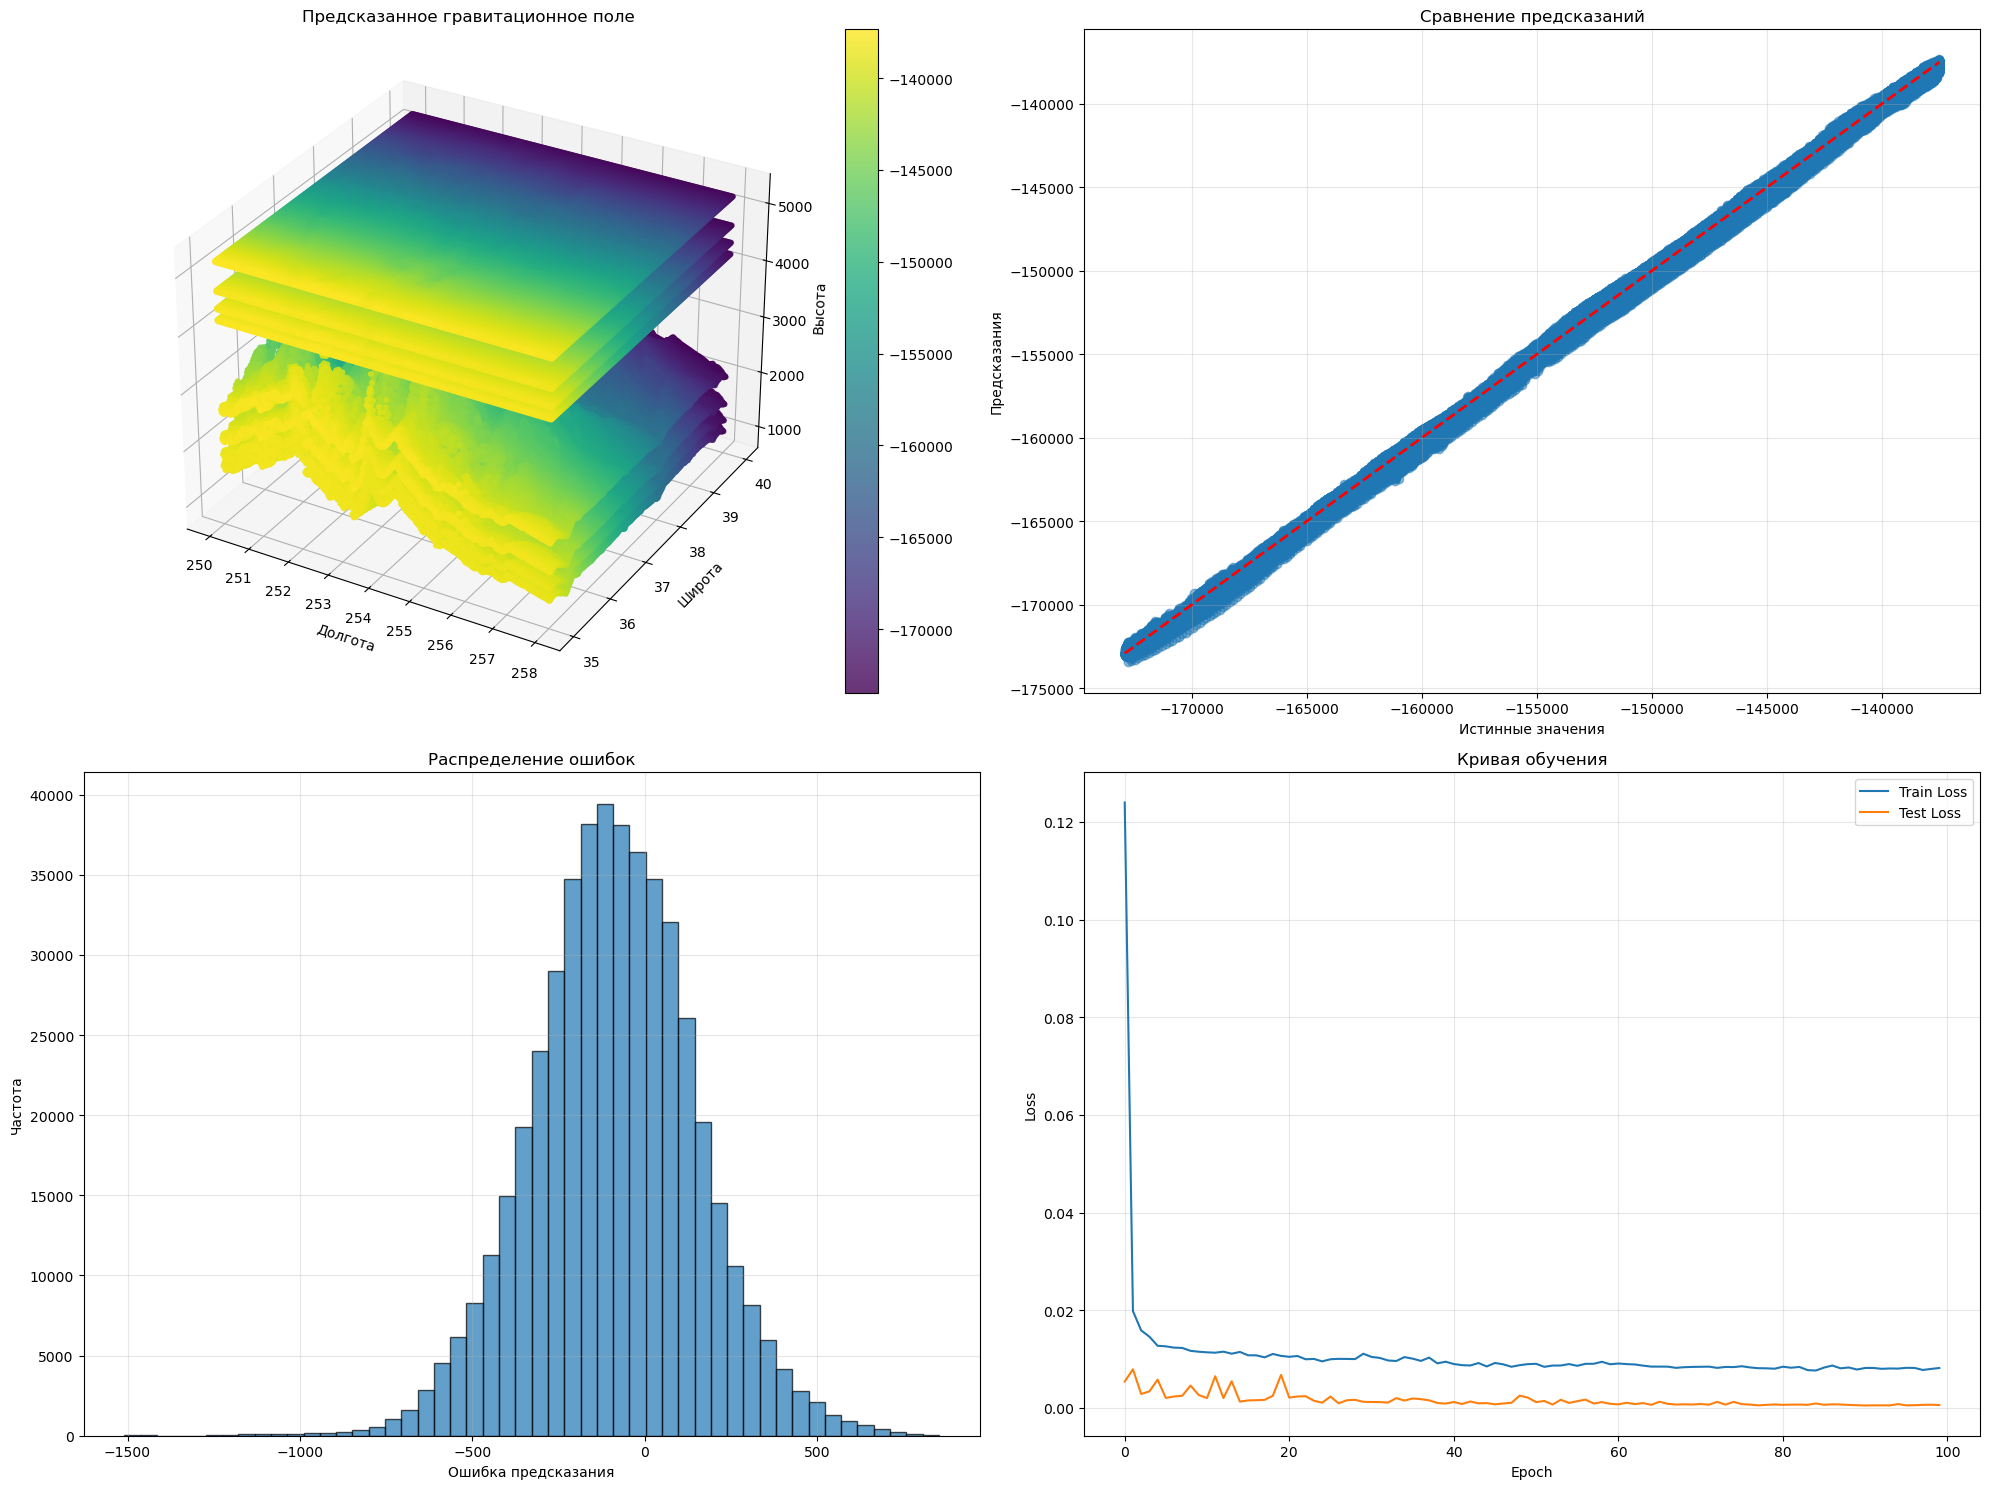

Модель сохранена: ./models/gravity_rnn_model.pth

Финальные результаты:
RMSE: 255.7233
R²: 0.9994


In [45]:
model, final_rmse, final_r2 = main()
if final_rmse is not None:
    print(f"\nФинальные результаты:")
    print(f"RMSE: {final_rmse:.4f}")
    print(f"R²: {final_r2:.4f}")